## Aging Curve Code

In [17]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd

out_df['age_rounded'] = np.round(out_df.age)

In [18]:
out_df.columns

Index(['player_id', 'full_name', 'team', 'position', 'age', 'season', 'week',
       'pts_ppr', 'pts_half_ppr', 'pts_std', 'pass_yd', 'pass_td', 'pass_int',
       'rush_yd', 'rush_td', 'rec', 'rec_yd', 'rec_td', 'rec_tgt', 'fgm',
       'fgmiss', 'xpm', 'xpmiss', 'fgm_50_59', 'fgm_60p', 'def_td', 'fum_lost',
       'sack', 'int', 'fum_rec', 'proj_pts_ppr', 'proj_pts_half_ppr',
       'proj_pts_std', 'age_rounded'],
      dtype='object')

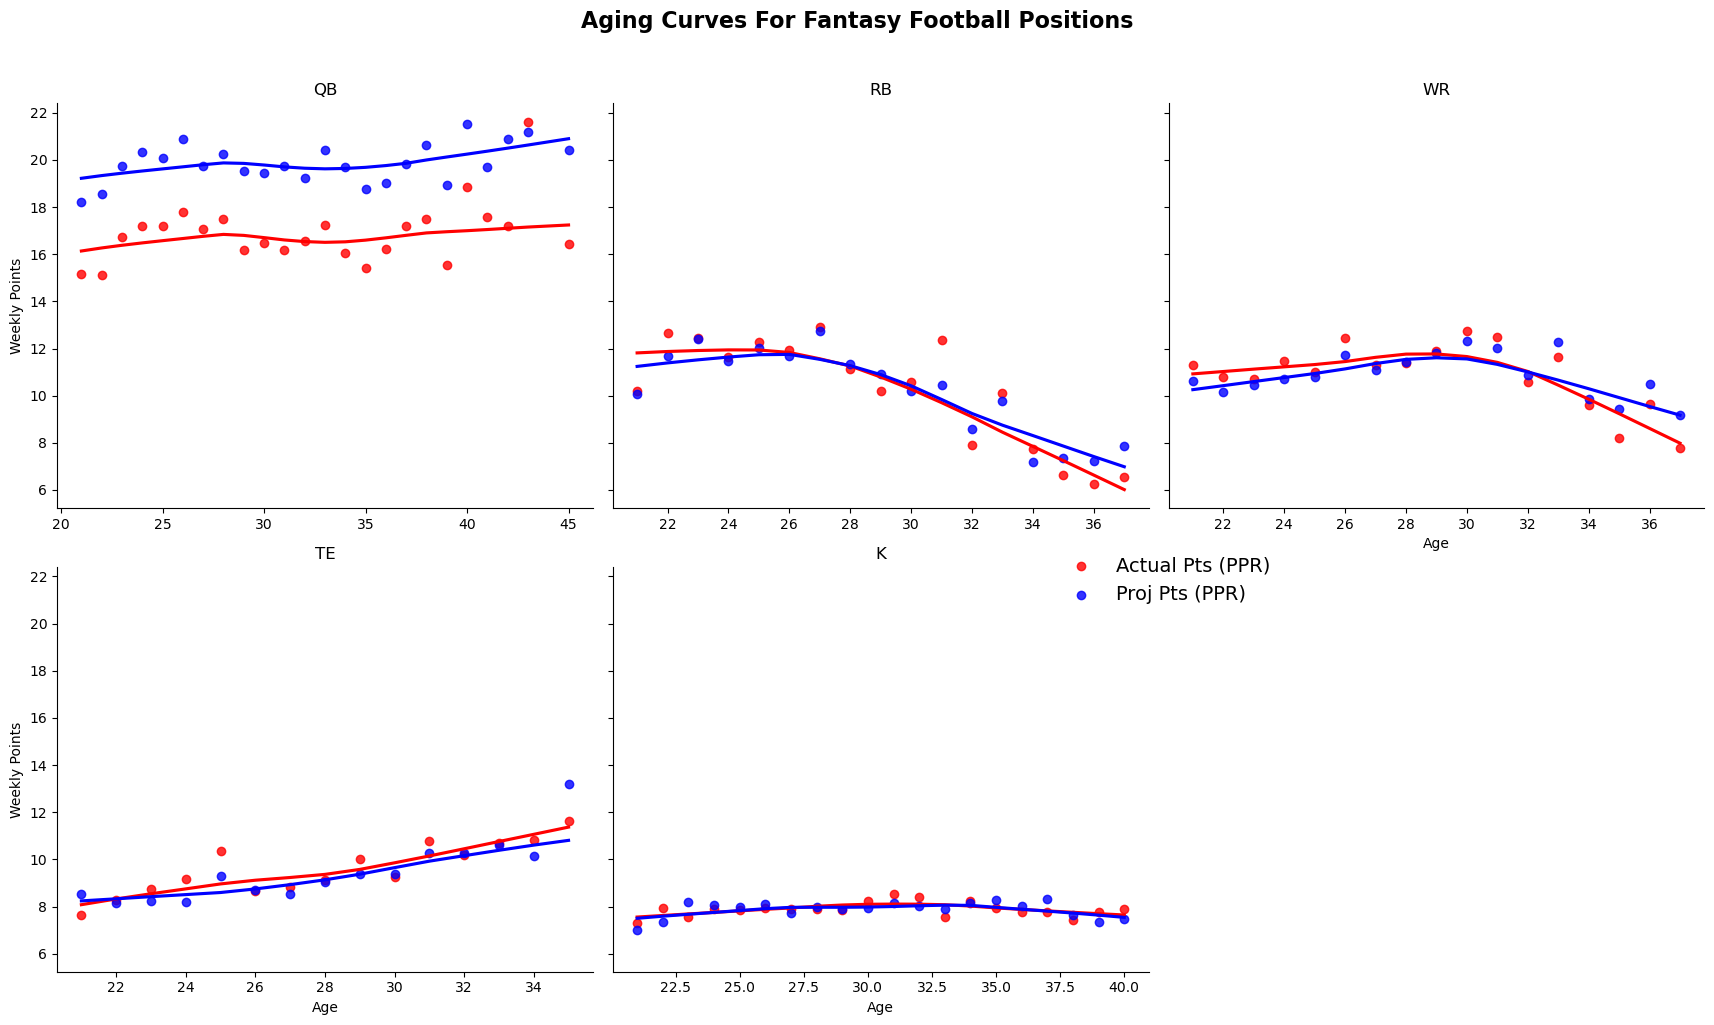

In [19]:
aging_df = out_df[out_df.proj_pts_ppr > 5].groupby(
    ['position', 'age_rounded']
).aggregate({
    'pts_ppr': 'mean',
    'proj_pts_ppr': 'mean' 
})

aging_df.reset_index(inplace=True, drop=False)

# Define position order
position_order = ['QB', 'RB', 'WR', 'TE', 'K']
aging_df['position'] = pd.Categorical(
    aging_df['position'], 
    categories=position_order, 
    ordered=True
)

aging_df_renamed = aging_df.rename(
    columns = {
    'pts_ppr' : 'Actual Pts (PPR)',
    'proj_pts_ppr' : 'Proj Pts (PPR)'
}).copy()

# Now use the melted approach for cleaner plotting
aging_df_melted = aging_df_renamed.melt(
    id_vars=['position', 'age_rounded'],
    value_vars=['Actual Pts (PPR)', 'Proj Pts (PPR)'],
    var_name='metric',
    value_name='value'
)

aging_plot = sns.lmplot(
    data=aging_df_melted,
    x='age_rounded',
    y='value',
    col='position',
    col_order=position_order,
    hue='metric',
    palette = {
        'Actual Pts (PPR)': 'red',
        'Proj Pts (PPR)' : 'blue'
    },
    col_wrap=3,
    facet_kws={'sharex': False},
    lowess=True,
    legend=False
)

aging_plot.fig.suptitle('Aging Curves For Fantasy Football Positions', 
                        y=1.02, fontsize=16, fontweight='bold')
aging_plot.set_axis_labels('Age', 'Weekly Points')
aging_plot.set_titles("{col_name}", size=12)
aging_plot.add_legend(bbox_to_anchor = (0.75,0.45), title = "",
                     fontsize = 14)
plt.tight_layout()
aging_plot.savefig('aging_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## Past Season to Future Performance Code

In [49]:
season_data = out_df.groupby(
    ['season','position', 'player_id']
).aggregate(
    {
    'pts_ppr':'sum',
    'proj_pts_ppr' : 'sum',
    'pass_yd': 'sum',
    'pass_td':'sum',
    'pass_int': 'sum',
    'rush_yd':'sum',
    'rush_td':'sum',
    'rec':'sum',
    'rec_yd':'sum',
    'rec_td':'sum',
    'rec_tgt': 'sum',
    'fgm': 'sum',
    'fgmiss':'sum',
    'xpm':'sum',
    'xpmiss':'sum',
    'fgm_50_59':'sum',
    'fgm_60p':'sum',
    'def_td':'sum',
    'fum_lost':'sum',
    'sack':'sum',
    'int':'sum',
    'fum_rec':'sum'   
    }
).reset_index(inplace = False, drop = False)

season_data

,season,position,player_id,pts_ppr,proj_pts_ppr,pass_yd,pass_td,pass_int,rush_yd,rush_td,...,fgmiss,xpm,xpmiss,fgm_50_59,fgm_60p,def_td,fum_lost,sack,int,fum_rec
0,2018,DEF,ARI,95.0,110.62,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,49.0,7.0,9.0
1,2018,DEF,ATL,86.0,116.78,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,37.0,15.0,4.0
2,2018,DEF,BAL,136.0,135.46,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,43.0,12.0,5.0
3,2018,DEF,BUF,132.0,111.86,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,36.0,16.0,11.0
4,2018,DEF,CAR,99.0,126.84,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35.0,13.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5830,2024,WR,9502,140.0,173.33,0.0,0.0,0.0,43.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5831,2024,WR,9504,121.9,90.97,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5832,2024,WR,9754,174.7,129.74,0.0,0.0,0.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5833,2024,WR,9756,212.5,172.21,0.0,0.0,0.0,20.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
### Creating a dictionary of positional dataframes
season_data_positional = {}

for position in season_data.position.unique():
    # filtering by position and players who averaged more than 4 pts per game
    positional_df = season_data[(season_data.position == position) & (season_data.proj_pts_ppr > 5)]
    # ensuring data is in the right order
    positional_df = positional_df.sort_values(by = ['player_id', 'season'])
    
    season_data_positional[position] = positional_df

In [51]:
season_data.columns

Index(['season', 'position', 'player_id', 'pts_ppr', 'proj_pts_ppr', 'pass_yd',
       'pass_td', 'pass_int', 'rush_yd', 'rush_td', 'rec', 'rec_yd', 'rec_td',
       'rec_tgt', 'fgm', 'fgmiss', 'xpm', 'xpmiss', 'fgm_50_59', 'fgm_60p',
       'def_td', 'fum_lost', 'sack', 'int', 'fum_rec'],
      dtype='object')

In [52]:
# Creating function to subset & add lag values for each data frame

def adding_lag_vars(data: pd.DataFrame, lag_cols: list):
    saved_cols = ['season', 'position', 'player_id',
                 'pts_ppr'] + lag_cols

    data = data[saved_cols]

    for col in lag_cols + ['pts_ppr']:
        data[f'{col}_lag'] = data.groupby('player_id')[col].shift(1)

    

    return data

In [53]:
qb_lag_vars = adding_lag_vars(
    season_data_positional['QB'].copy(),
    ['pass_yd', 'pass_td', 'pass_int', 'rush_yd', 'rush_td']
).reset_index(inplace = False, drop = True)

rb_lag_vars = adding_lag_vars(
    season_data_positional['RB'].copy(),
    ['rush_yd', 'rush_td', 'rec', 'rec_yd', 'rec_td', 'rec_tgt']
).reset_index(inplace = False, drop = True)

wr_lag_vars = adding_lag_vars(
    season_data_positional['WR'].copy(),
    ['rec', 'rec_yd', 'rec_td', 'rec_tgt']
).reset_index(inplace = False, drop = True)


te_lag_vars = adding_lag_vars(
    season_data_positional['TE'].copy(),
    ['rec', 'rec_yd', 'rec_td', 'rec_tgt']
).reset_index(inplace = False, drop = True)

kicker_lag_vars = adding_lag_vars(
    season_data_positional['K'].copy(),
    ['fgm', 'fgmiss', 'xpm','xpmiss', 'fgm_50_59', 'fgm_60p']
).reset_index(inplace = False, drop = True)


def_lag_vars = adding_lag_vars(
    season_data_positional['DEF'].copy(),
    ['def_td', 'fum_lost', 'sack', 'int', 'fum_rec']
)

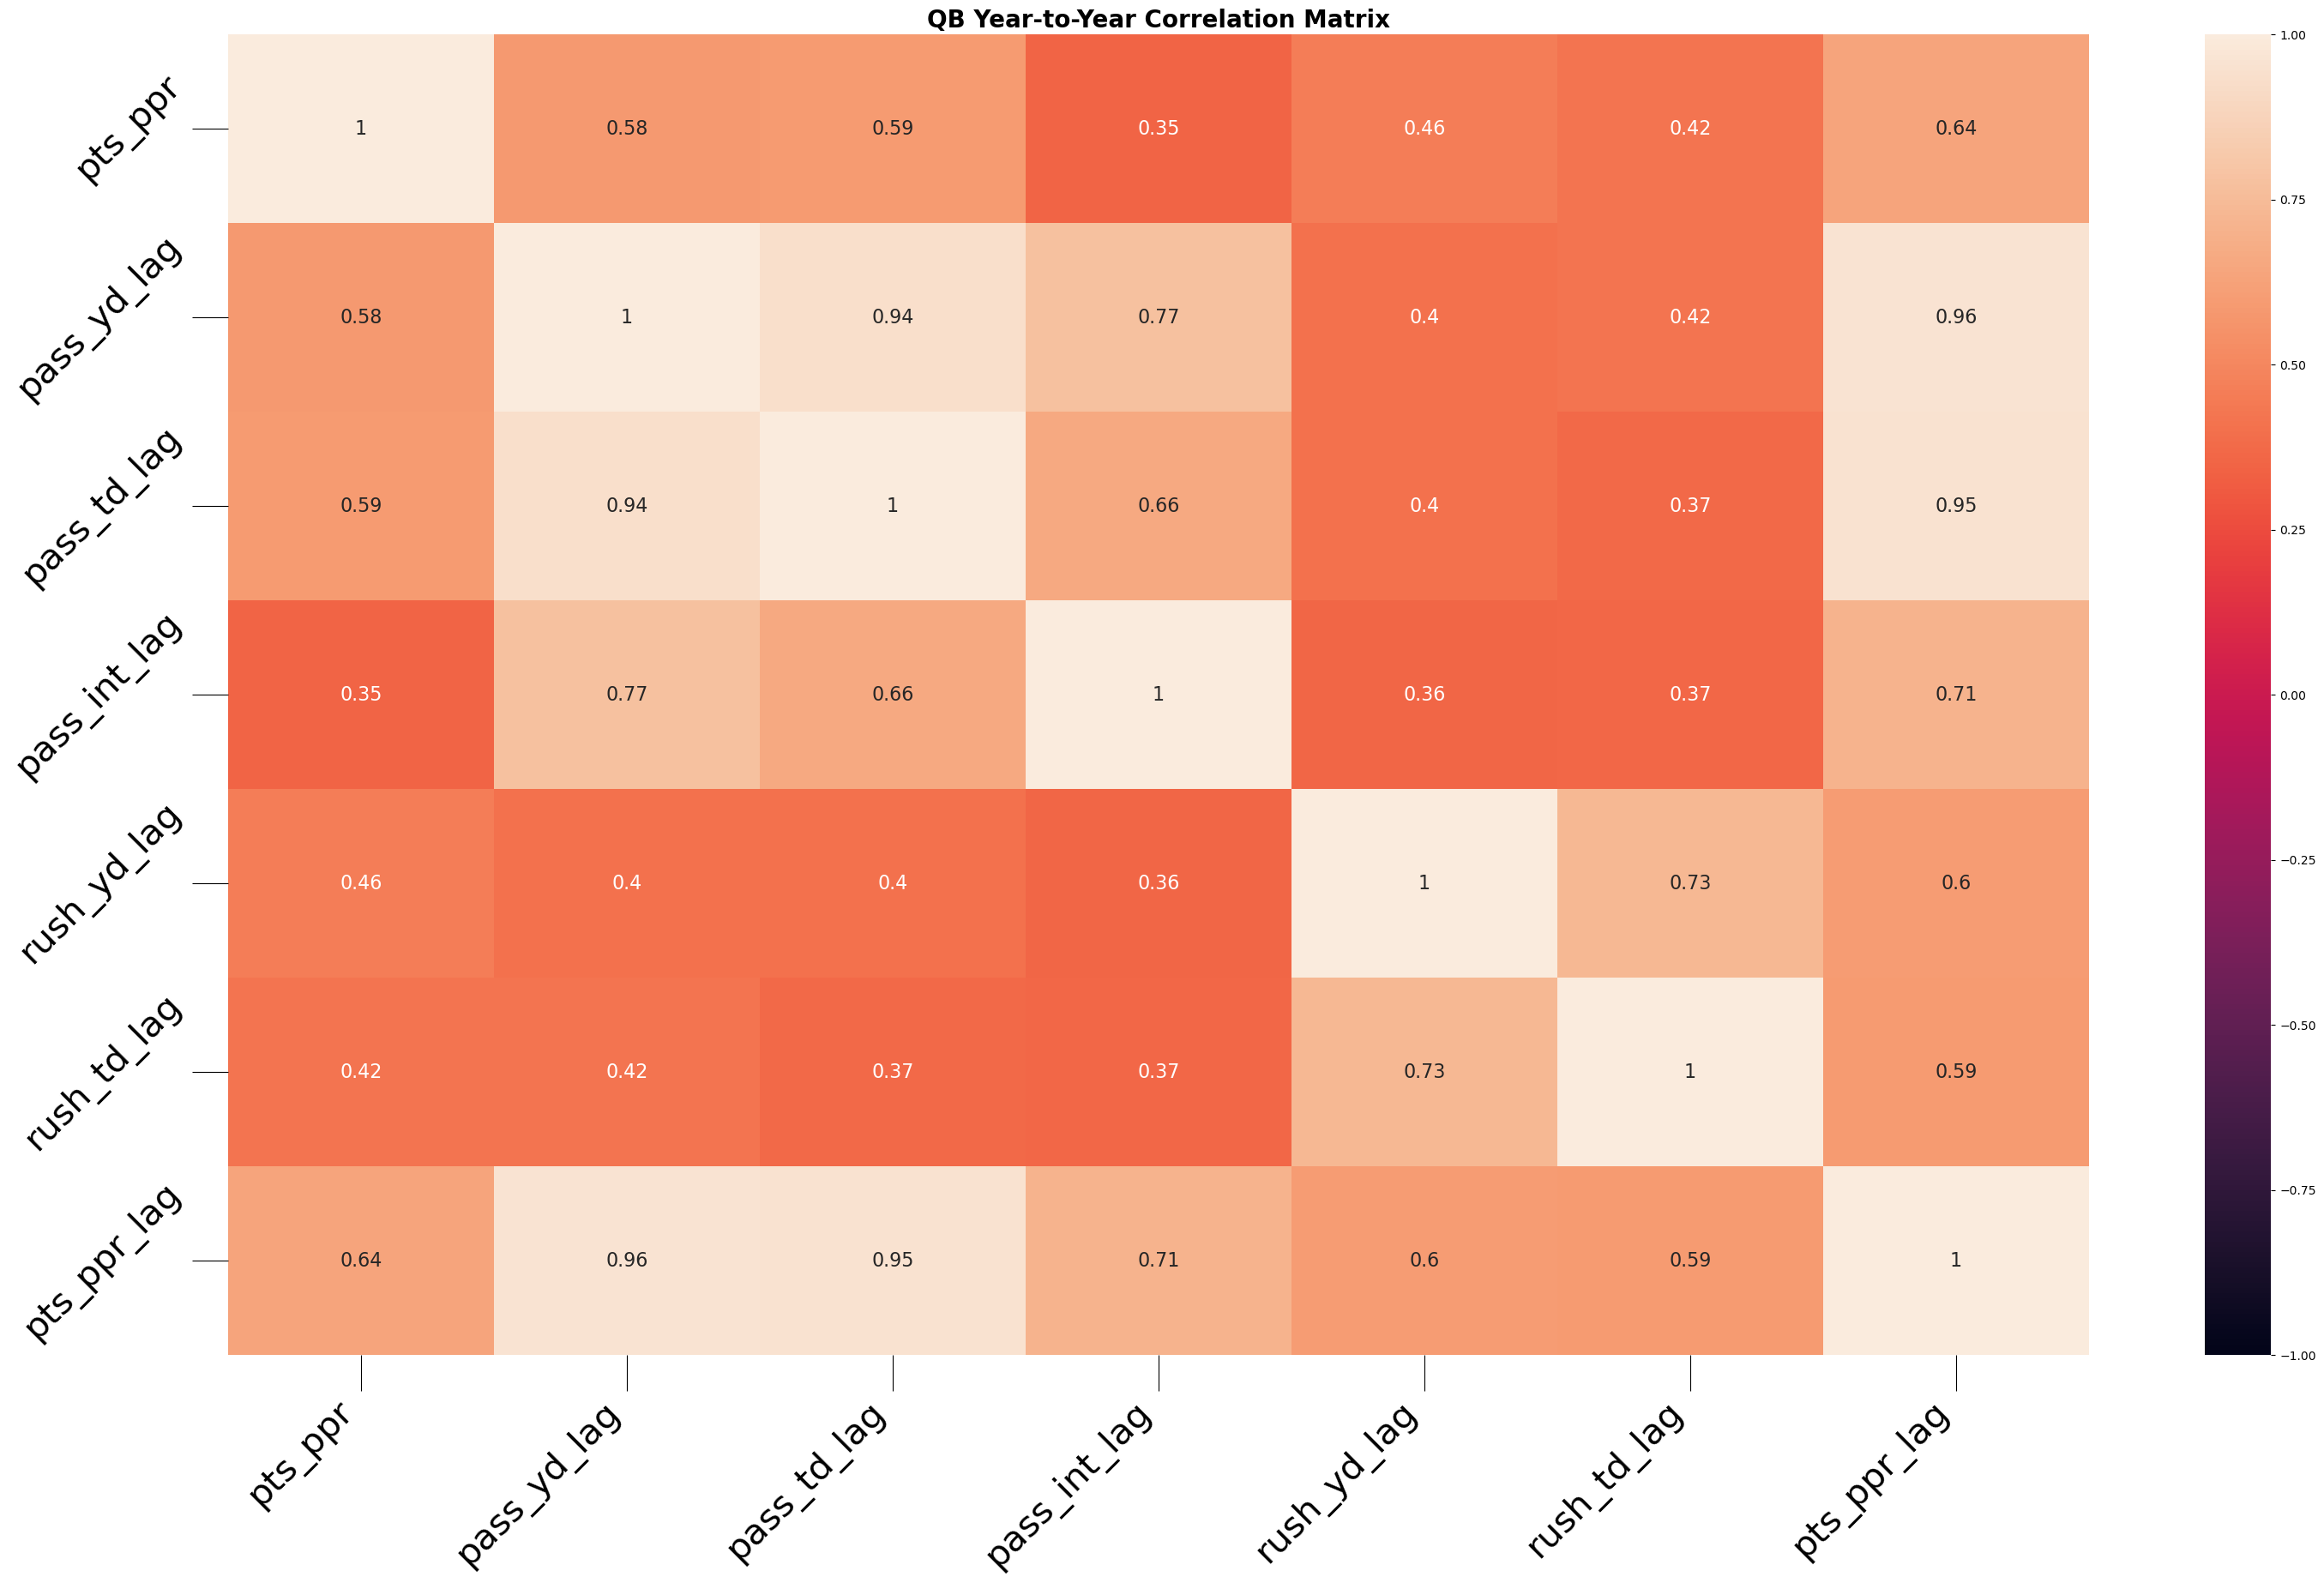

In [54]:

def plot_corr_matrix(data: pd.DataFrame, cols: list, plot_title: str):
    plt.figure(figsize = (35,20))
    ax = sns.heatmap(data[cols].corr(numeric_only=True), annot=True,
            annot_kws = {'fontsize': 16},
            vmin =  -1,
            vmax = 1
           )
    plt.title(label = plot_title, fontsize = 20, fontweight = 'bold')
    ax.tick_params(axis = 'both', labelsize = 30, size =30)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
    plt.savefig(f'{plot_title}.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_corr_matrix(data = qb_lag_vars, cols = ['pts_ppr', 'pass_yd_lag', 'pass_td_lag', 
            'pass_int_lag', 'rush_yd_lag', 'rush_td_lag', 'pts_ppr_lag'],
                 plot_title = "QB Year-to-Year Correlation Matrix")

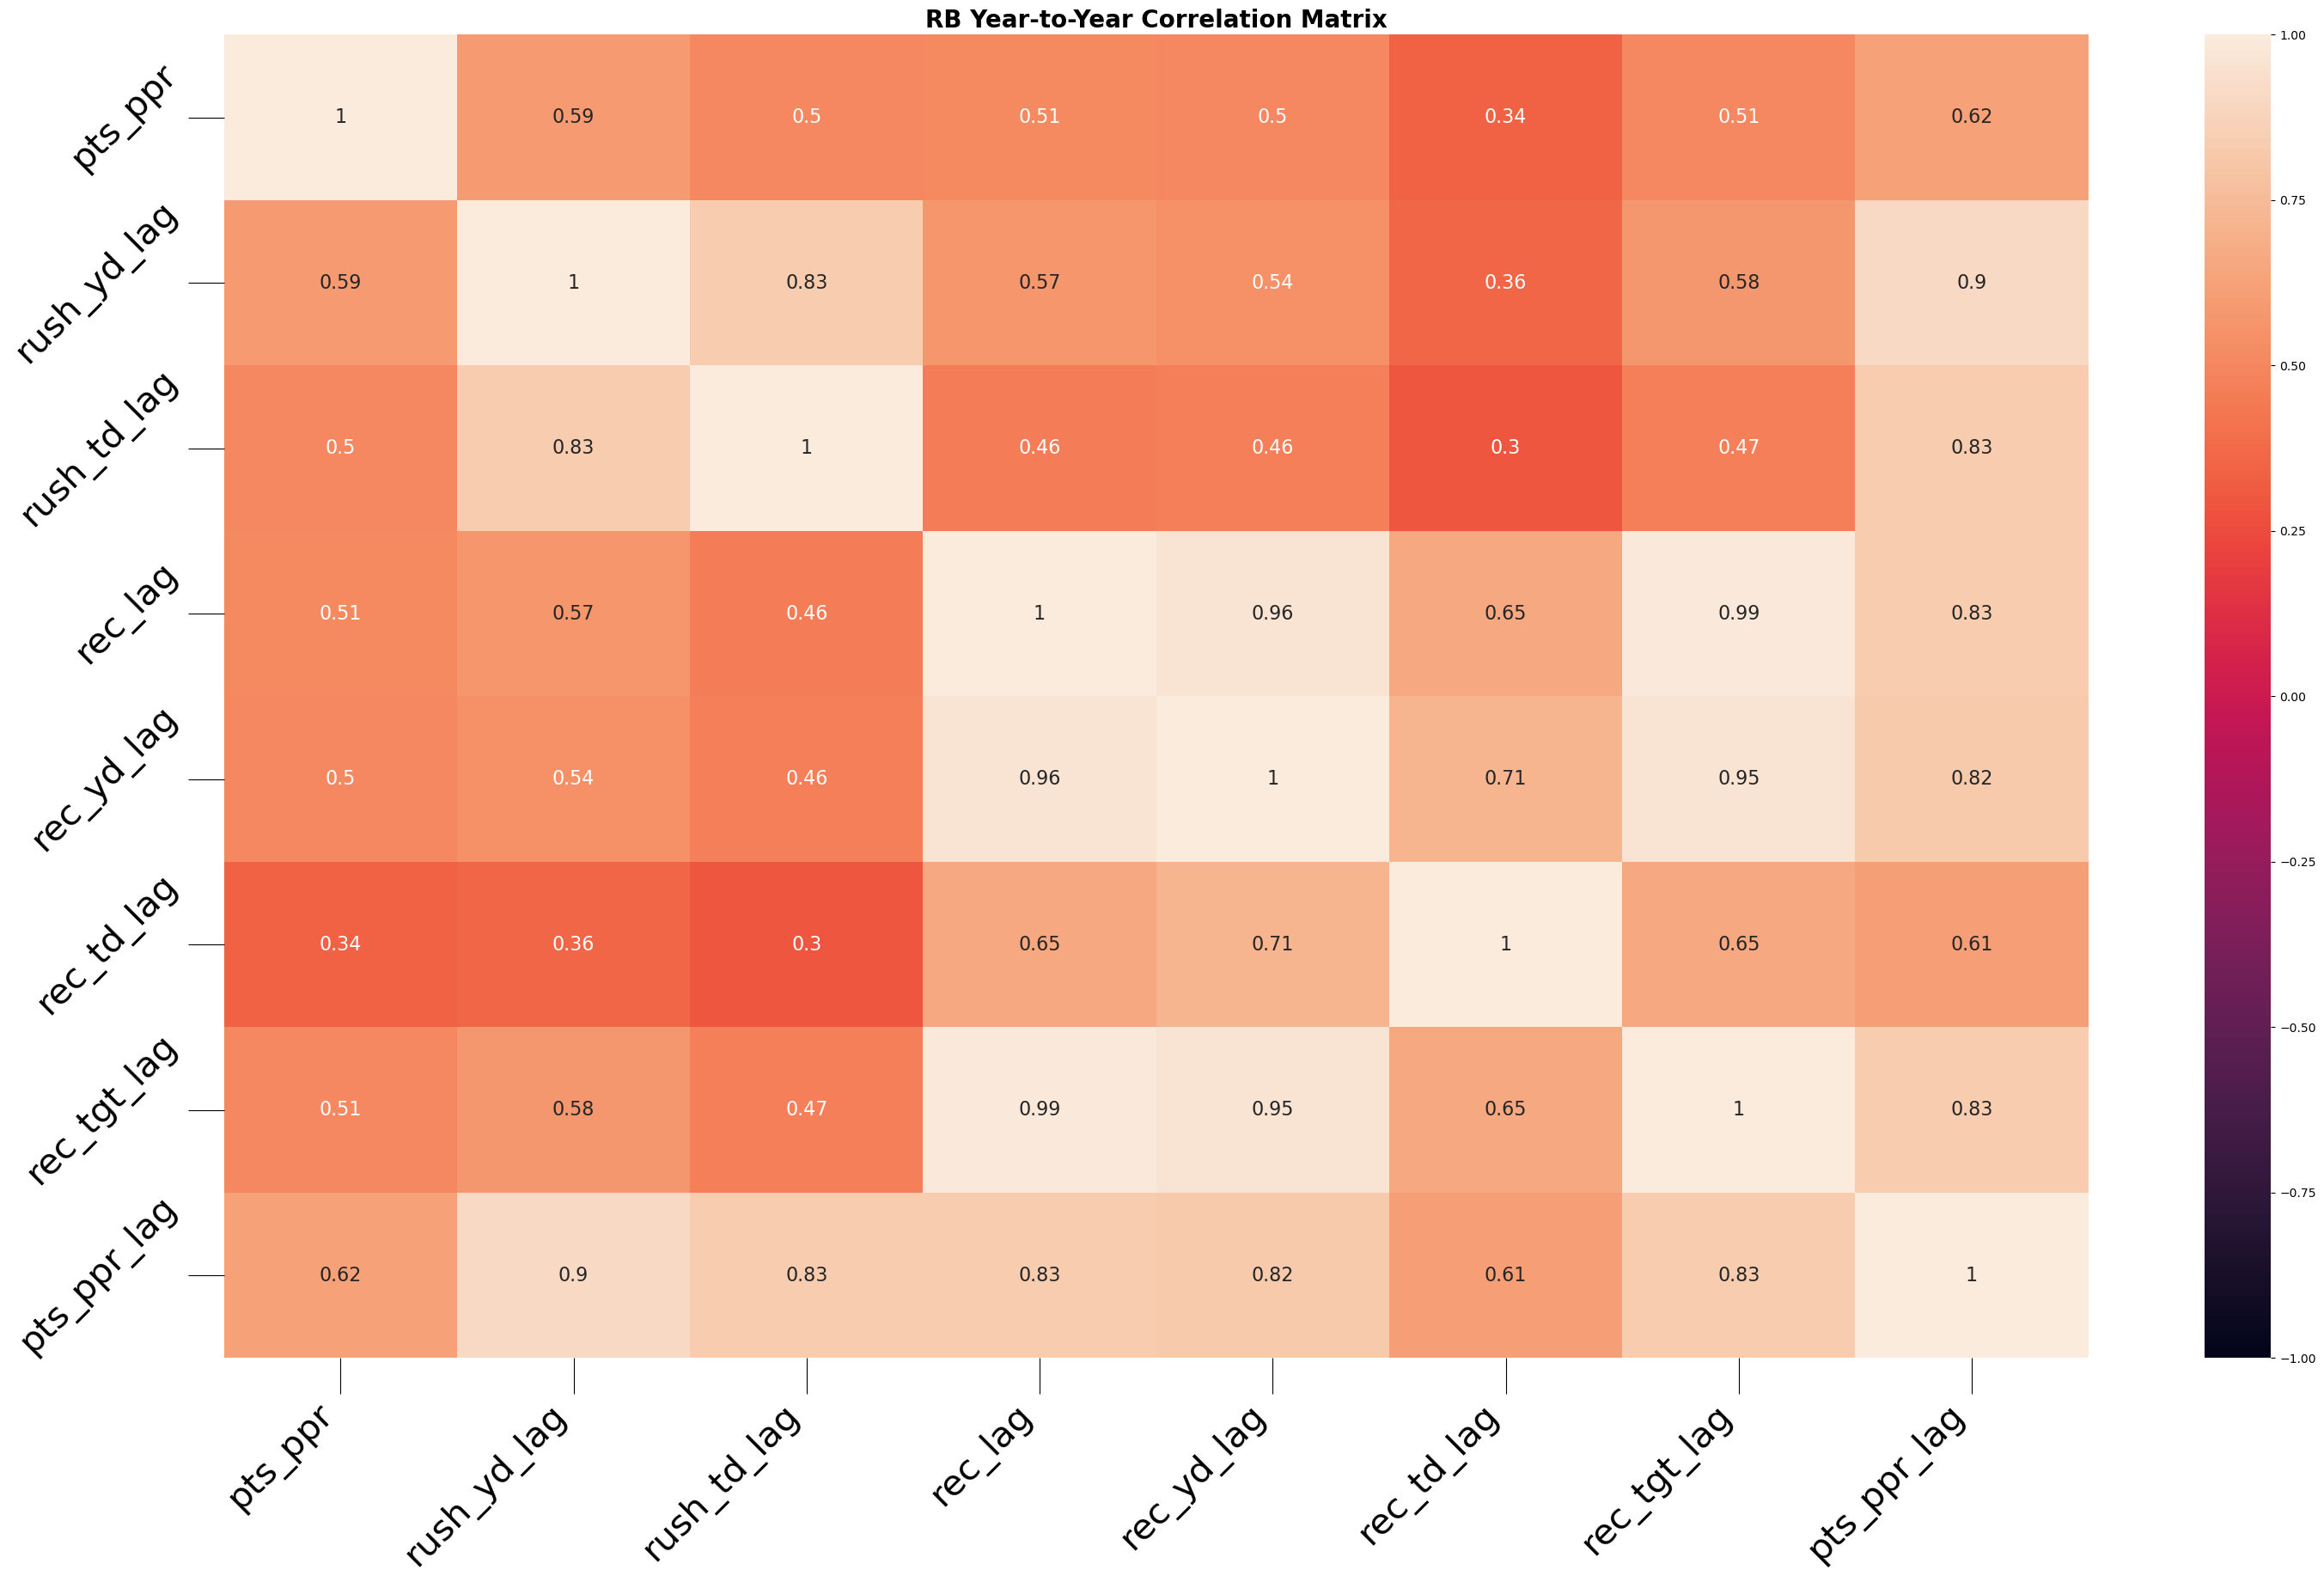

In [55]:
plot_corr_matrix(
    data = rb_lag_vars,
    cols = [
        'pts_ppr', 'rush_yd_lag', 'rush_td_lag', 'rec_lag',
        'rec_yd_lag', 'rec_td_lag', 'rec_tgt_lag', 'pts_ppr_lag'
    ],
    plot_title = "RB Year-to-Year Correlation Matrix"
)

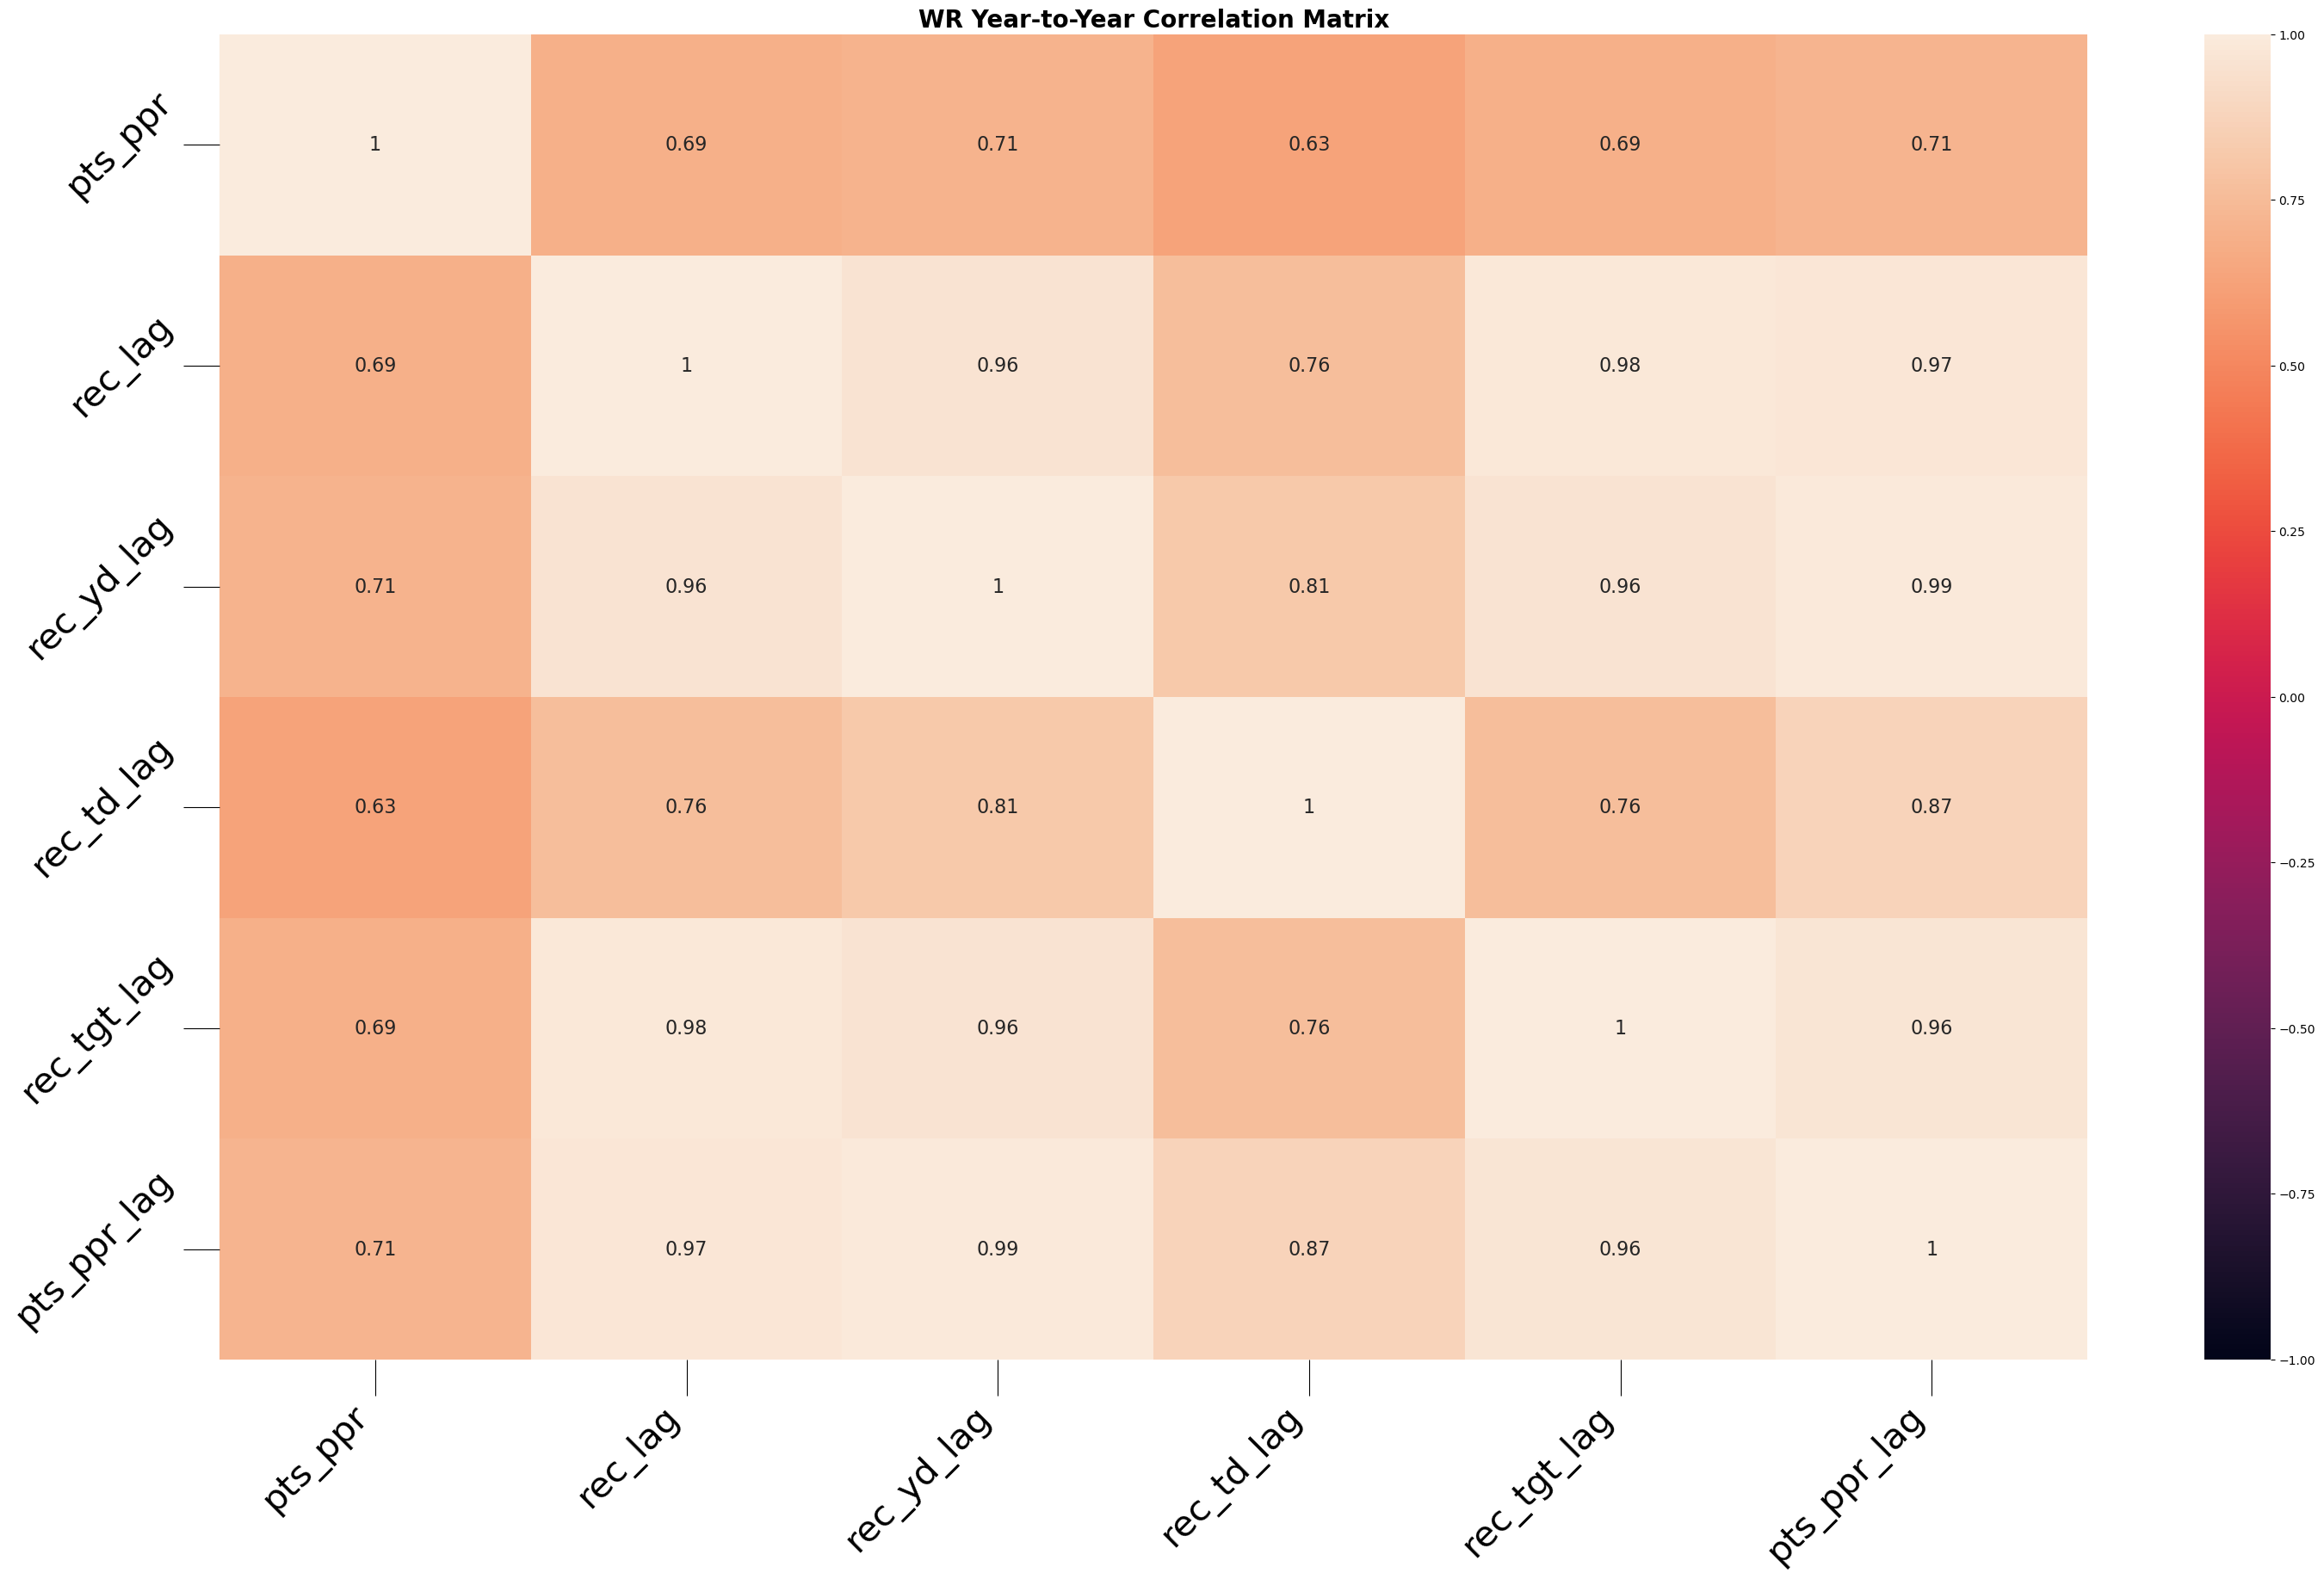

In [56]:
plot_corr_matrix(
    data = wr_lag_vars,
    cols = [
        'pts_ppr', 'rec_lag',
        'rec_yd_lag', 'rec_td_lag', 'rec_tgt_lag', 'pts_ppr_lag'
    ],
    plot_title = "WR Year-to-Year Correlation Matrix"
)

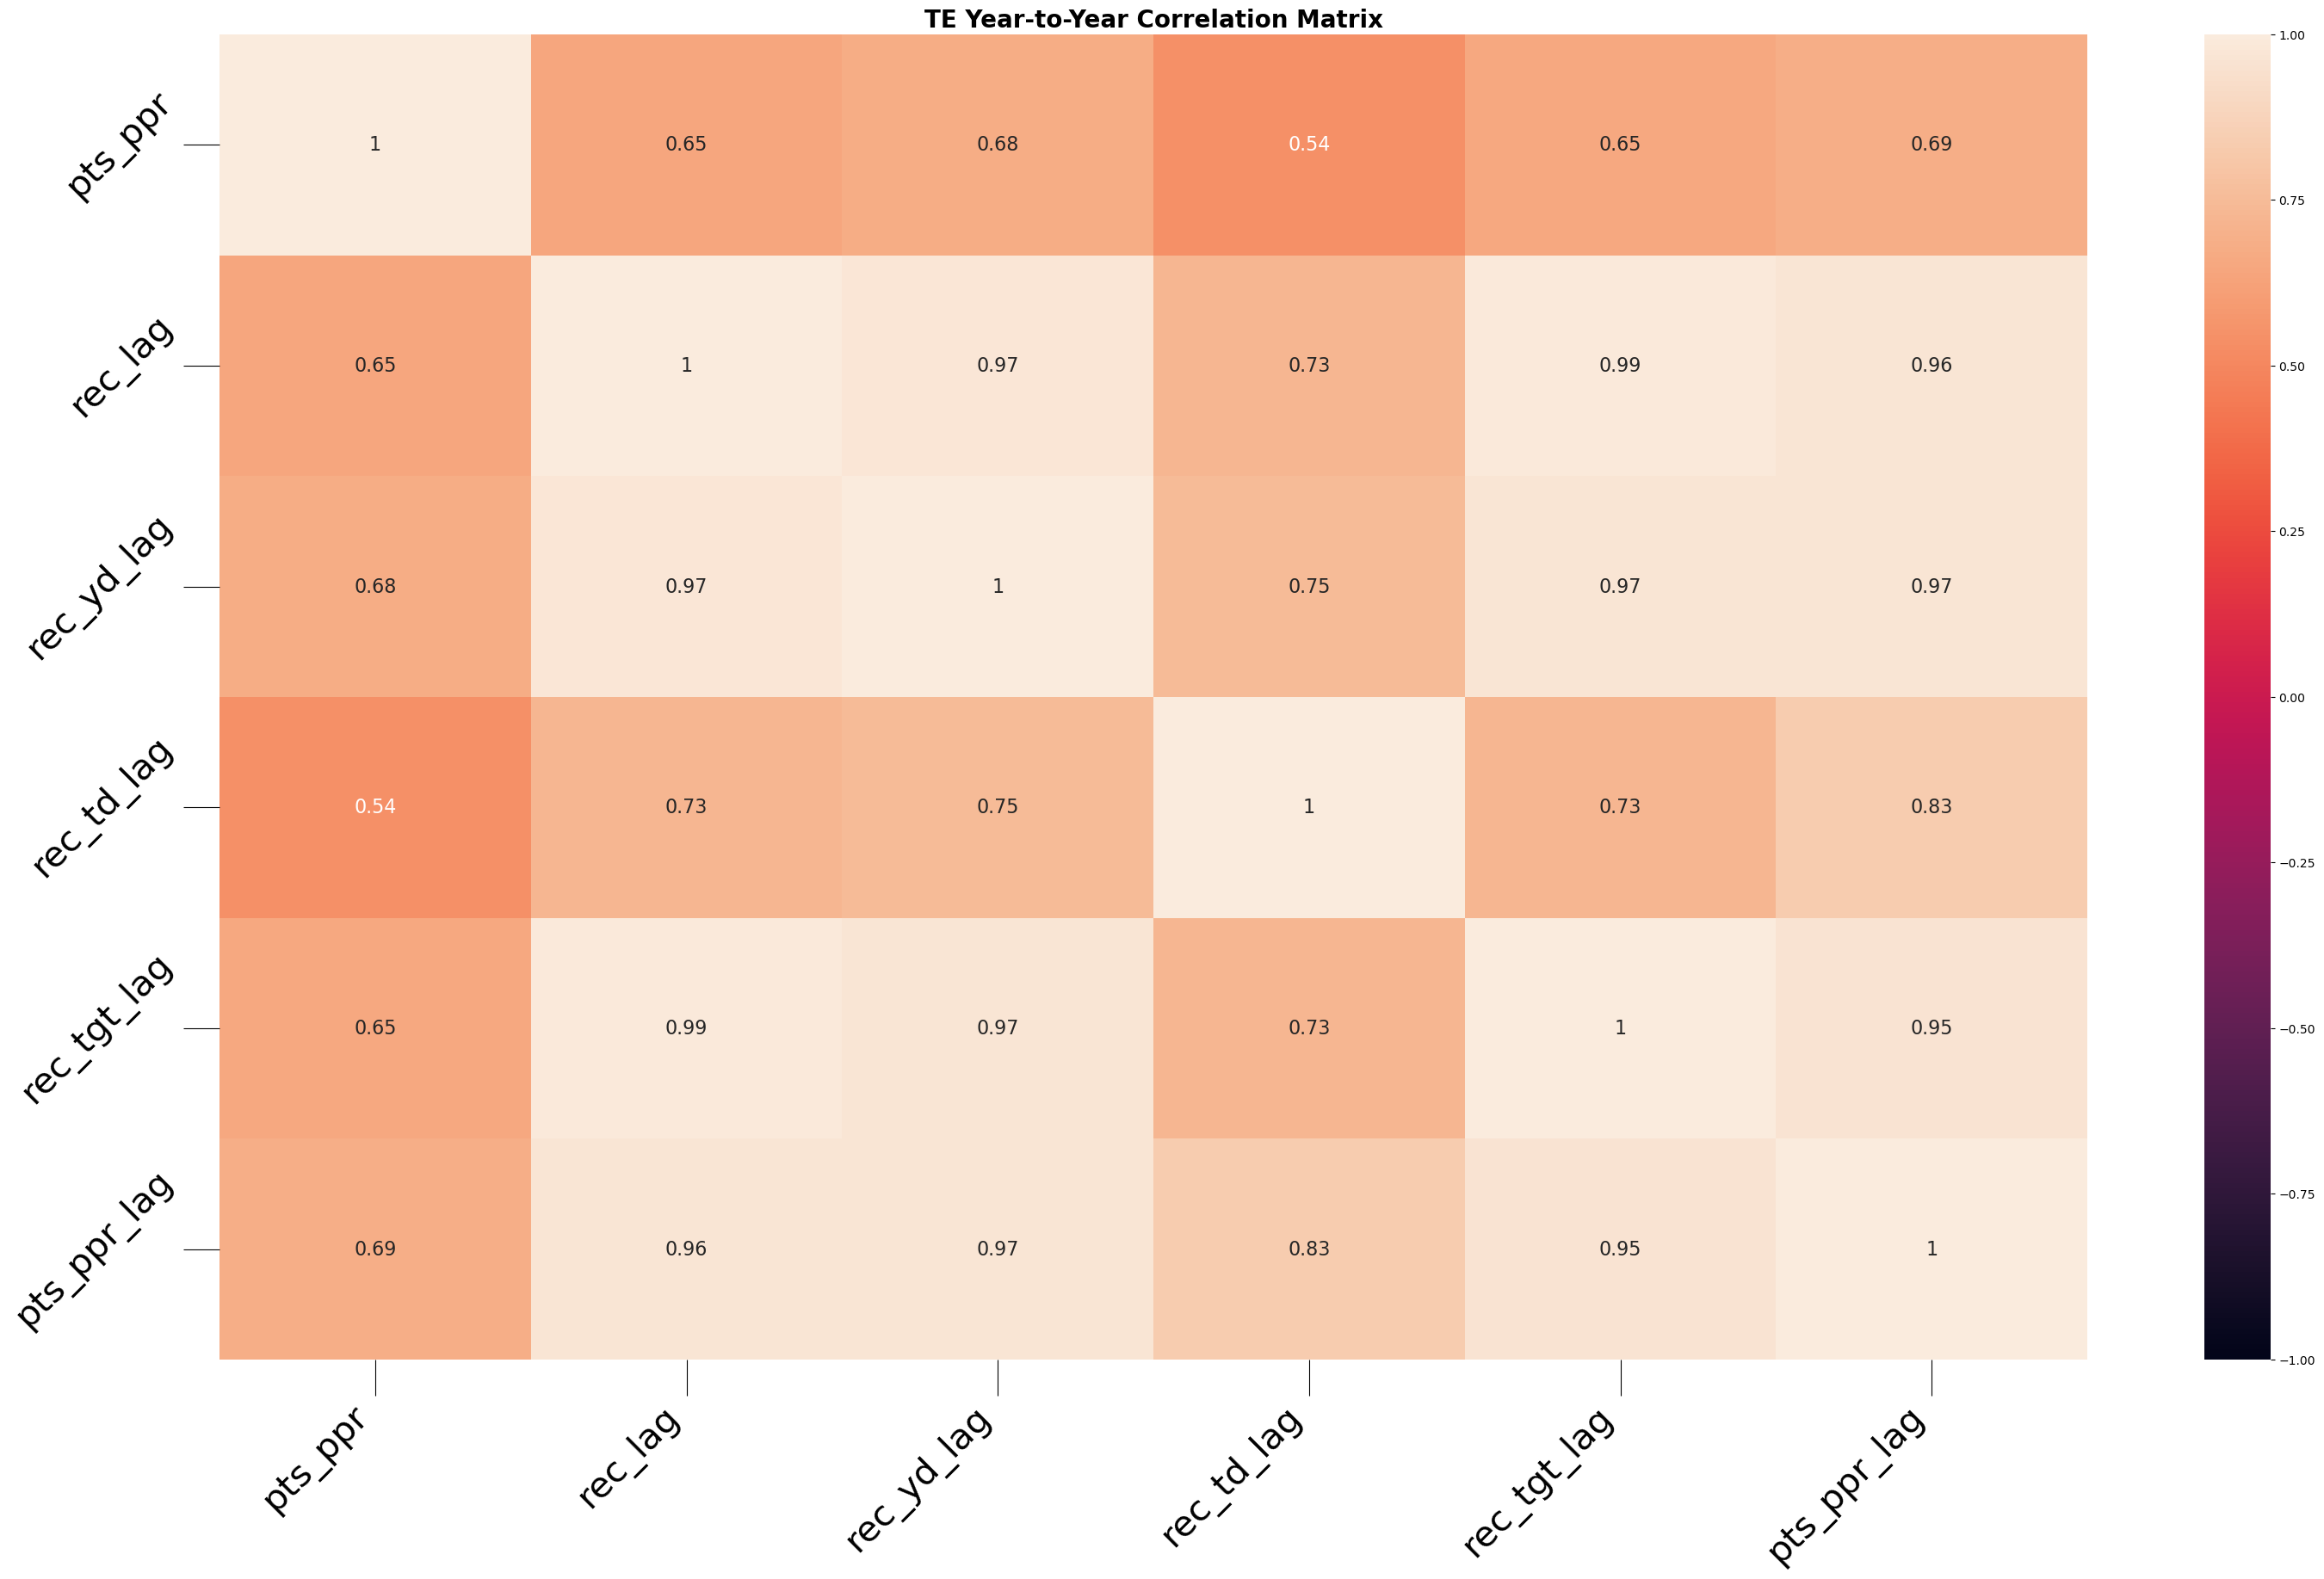

In [57]:
plot_corr_matrix(
    data = te_lag_vars,
    cols = [
        'pts_ppr', 'rec_lag',
        'rec_yd_lag', 'rec_td_lag', 'rec_tgt_lag', 'pts_ppr_lag'
    ],
    plot_title = "TE Year-to-Year Correlation Matrix"
)

In [58]:
kicker_lag_vars.columns

Index(['season', 'position', 'player_id', 'pts_ppr', 'fgm', 'fgmiss', 'xpm',
       'xpmiss', 'fgm_50_59', 'fgm_60p', 'fgm_lag', 'fgmiss_lag', 'xpm_lag',
       'xpmiss_lag', 'fgm_50_59_lag', 'fgm_60p_lag', 'pts_ppr_lag'],
      dtype='object')

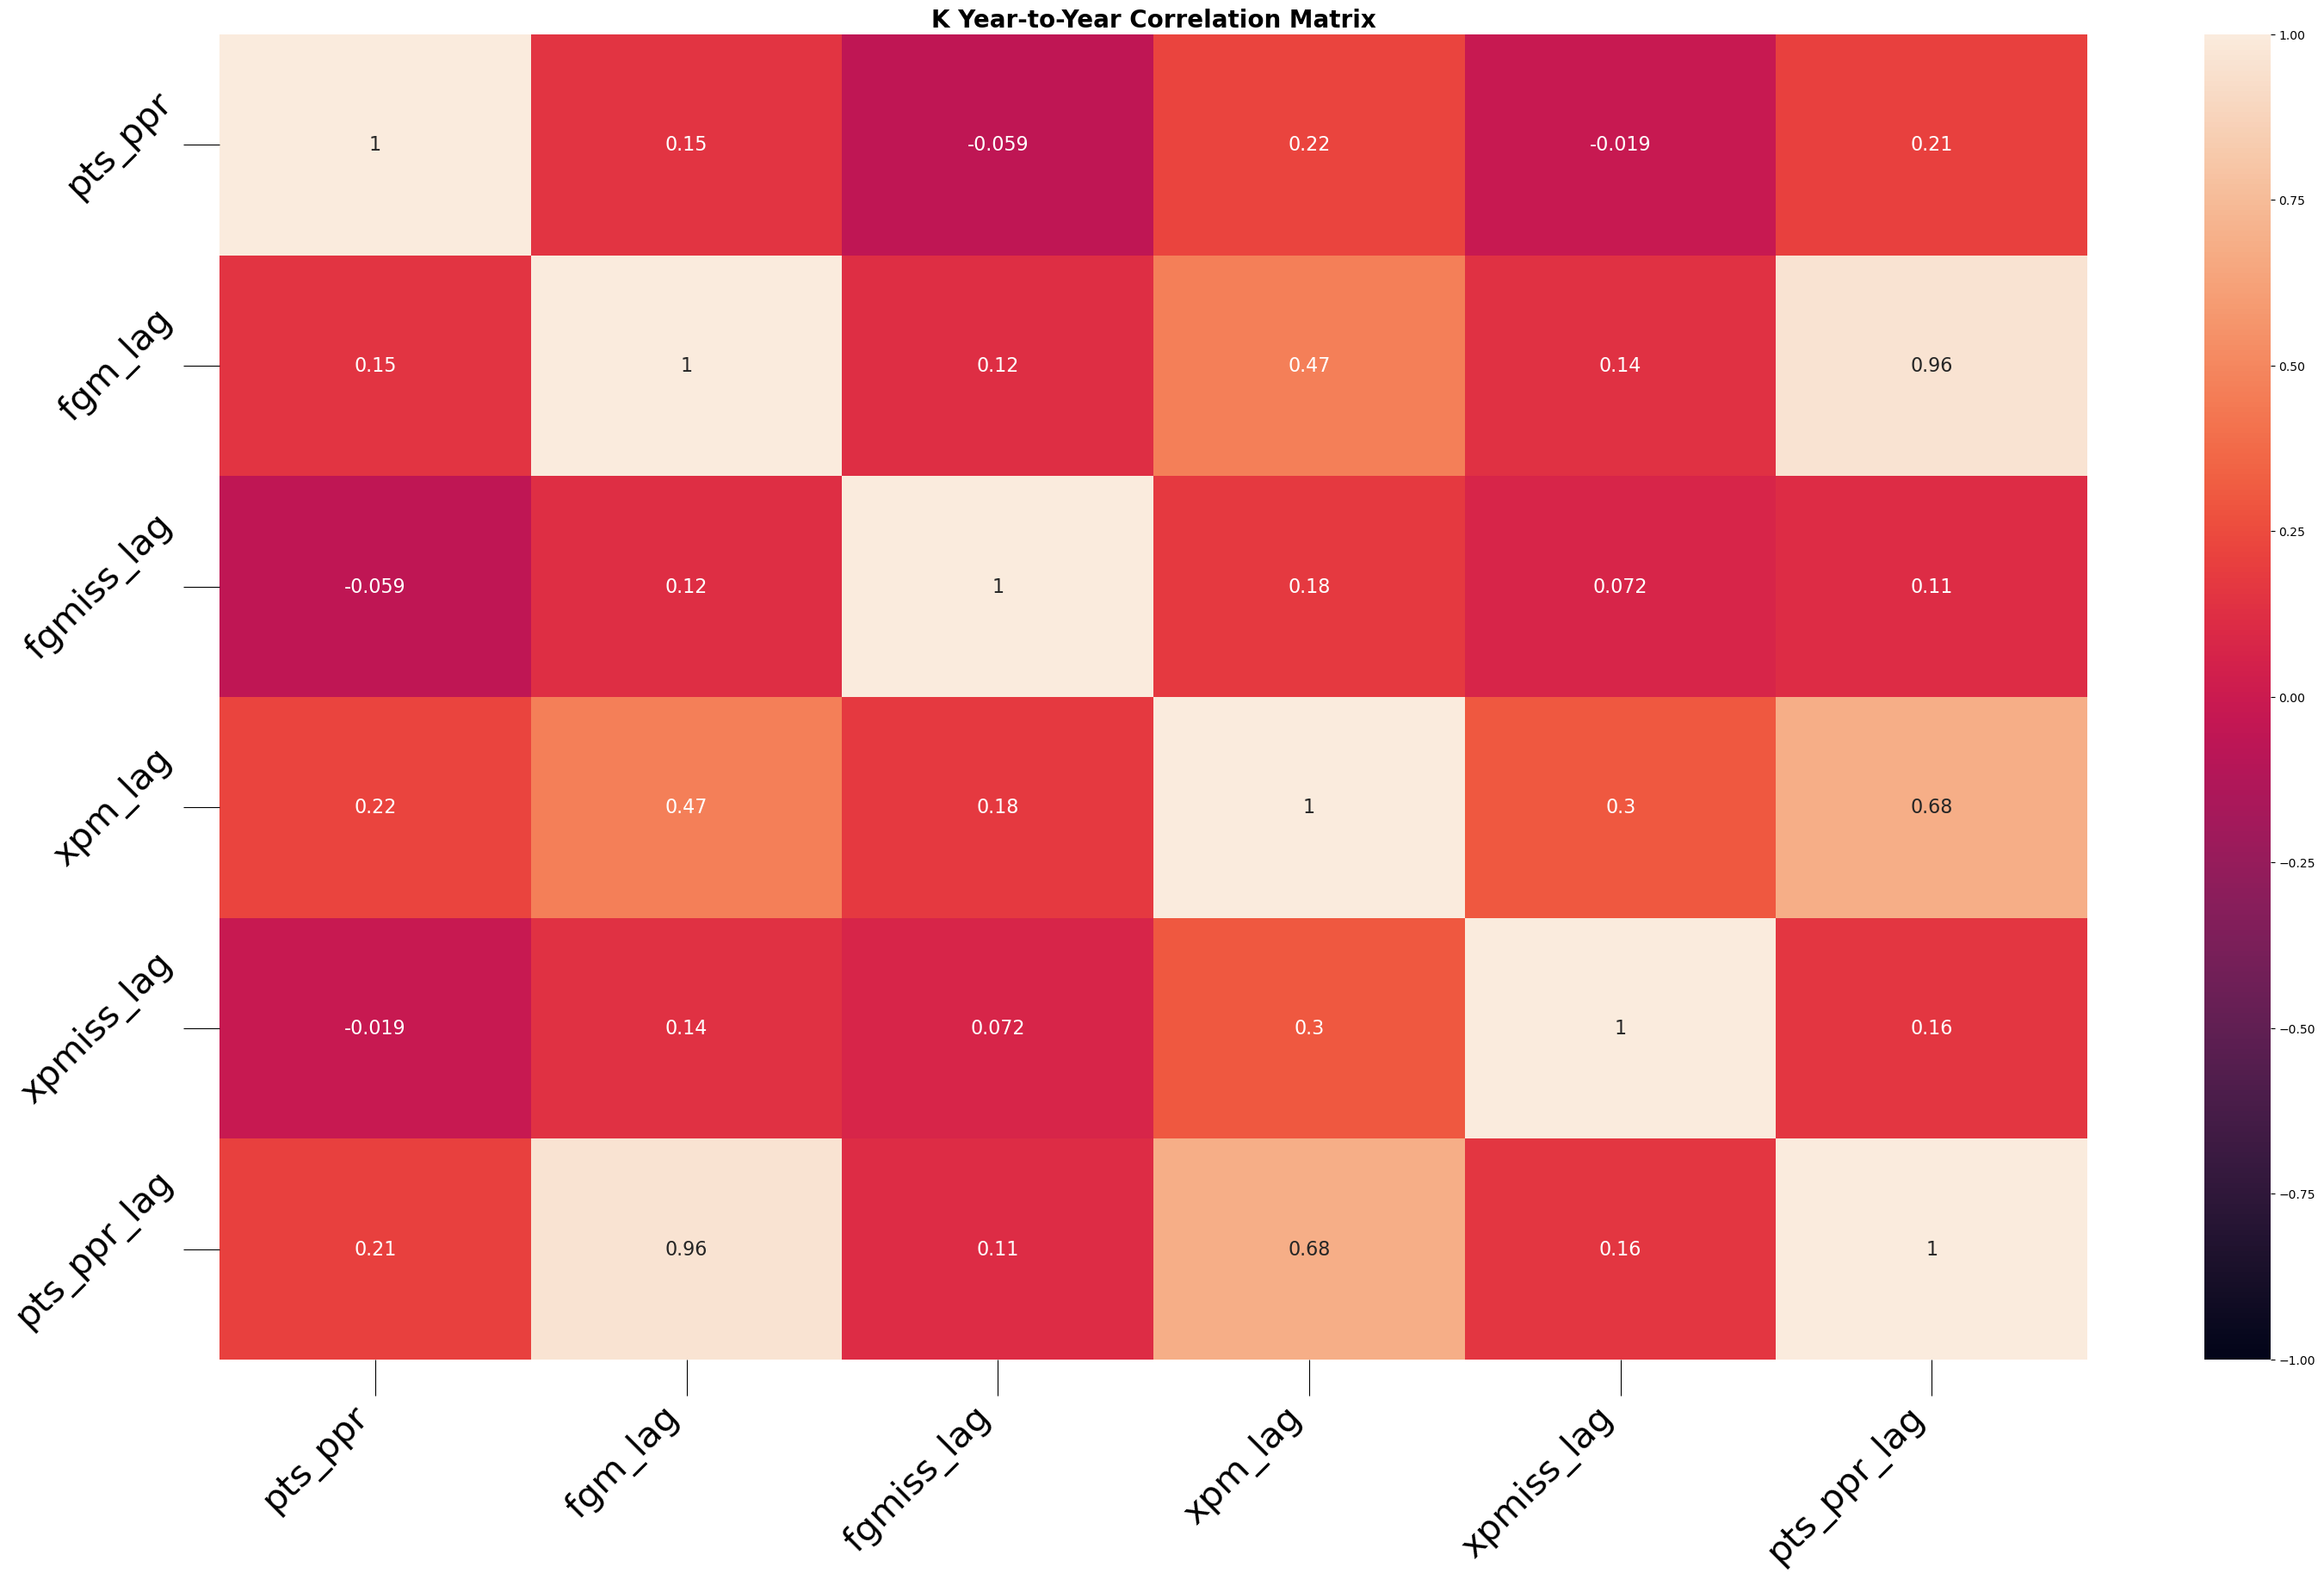

In [59]:
plot_corr_matrix(
    data = kicker_lag_vars,
    cols = [
        'pts_ppr', 'fgm_lag', 'fgmiss_lag', 'xpm_lag', 'xpmiss_lag',
        'pts_ppr_lag'
    ],
    plot_title = "K Year-to-Year Correlation Matrix"
)

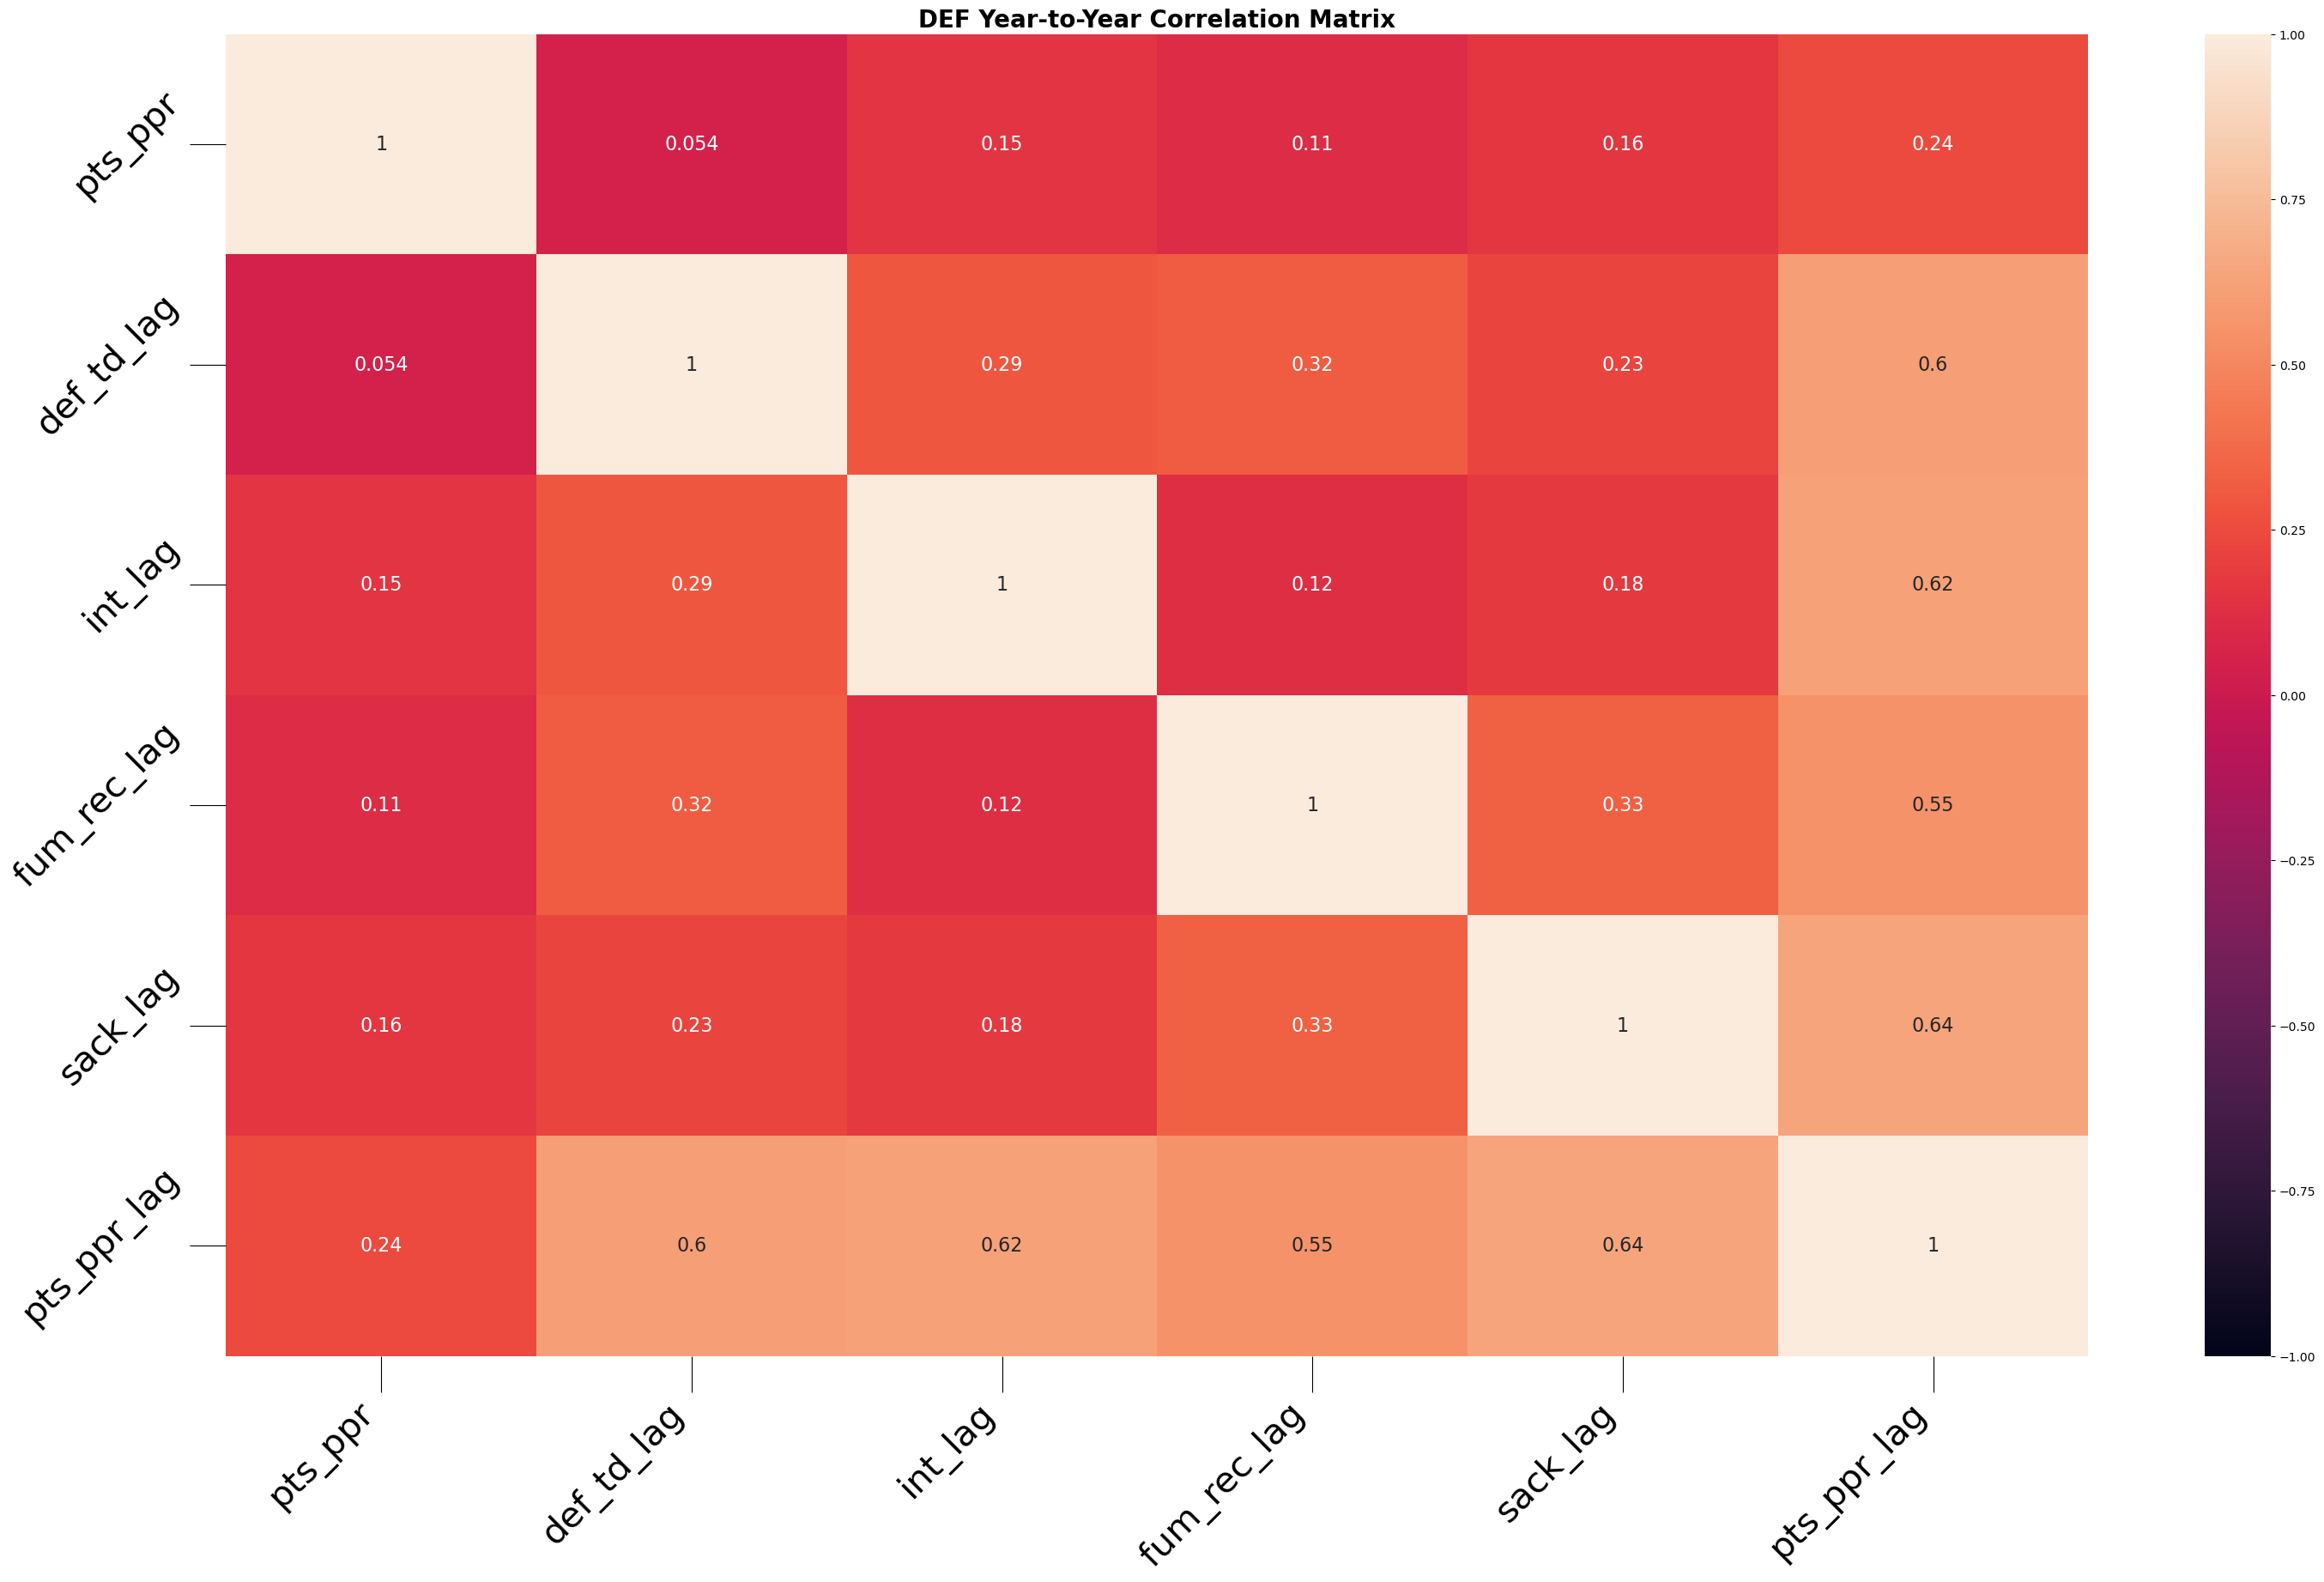

In [60]:
plot_corr_matrix(
    data = def_lag_vars,
    cols = [
        'pts_ppr', 'def_td_lag', 'int_lag', 'fum_rec_lag', 'sack_lag',
        'pts_ppr_lag'
    ],
    plot_title = "DEF Year-to-Year Correlation Matrix"
)